<a href="https://colab.research.google.com/github/cibelerusso/FundamentosemCienciasdeDados/blob/main/Notebooks/Fundamentos_em_Ciencias_de_Dados_Aula_15_Aprendizado_Nao_Supervisionado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizado Não-Supervisionado

## 5500004 Fundamentos em Ciências de Dados

## Profa. Cibele Russo - ICMC USP

Fonte principal: MOREIRA, João Mendes; CARVALHO, André C. P. L. F. de; HORVÁTH, Tomáš. **A General Introduction to Data Analytics**. 1. ed. Hoboken, NJ: John Wiley & Sons, Inc., 2019.

Notebook criado com apoio de ferramentas de IA generativa: NotebookLM e ChatGPT.

Dados utilizados neste notebook: base **Iris**, disponível no pacote `scikit-learn`, e uma pequena base artificial de transações para regras de associação.

Materiais complementares sugeridos:

Playlist Análise Multivariada e Aprendizado Não-Supervisionado: https://www.youtube.com/playlist?list=PLt7qVSwRVn5bg14OLl6dHTNnXVrEM6UiS

Análise de agrupamentos: https://youtu.be/zyLDAnQMnbo?si=mmd8Eck-EugqUM_o

Análise de agrupamentos - Aplicação em Python: https://youtu.be/d_CJGaAbC7o?si=2yAtCxoud7x2U-WS

# Aprendizado Não-Supervisionado

No **aprendizado supervisionado**, temos uma variável resposta, ou rótulo, que guia o processo de aprendizagem. Já no **aprendizado não-supervisionado**, trabalhamos apenas com os atributos observados, sem uma classe conhecida previamente.

Nesta aula, estudaremos:

- o conceito de aprendizado não-supervisionado;
- tarefas descritivas em Ciência de Dados;
- medidas de distância;
- agrupamento, ou **clustering**;
- algoritmo **K-médias** **(K-means)**;
- método do **cotovelo** e coeficiente de **silhueta**;
- agrupamento hierárquico e **dendrogramas**;
- noções de mineração de padrões frequentes;
- aplicação prática com a base **Iris**.

## 1. Carregamento das bibliotecas

Vamos usar bibliotecas para manipulação de dados, visualização, algoritmos de agrupamento e avaliação descritiva dos grupos encontrados.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import pairwise_distances

from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
np.random.seed(42)

# 2. O que é aprendizado não-supervisionado?

No aprendizado não-supervisionado, o conjunto de dados não possui rótulos conhecidos. O objetivo não é prever uma resposta, mas **identificar padrões** nos dados.

Exemplos de perguntas típicas:

- Existem grupos naturais de clientes?
- Há perfis distintos de flores ou espécies com base em medidas morfológicas?
- Existem produtos que costumam ser comprados juntos?
- Há observações atípicas ou muito diferentes das demais?

O foco principal é a **análise descritiva**: resumir, agrupar, visualizar e interpretar padrões presentes nos dados.

## 2.1 Esquema geral

A ideia é partir de uma matriz de dados sem rótulos e procurar alguma estrutura interna.

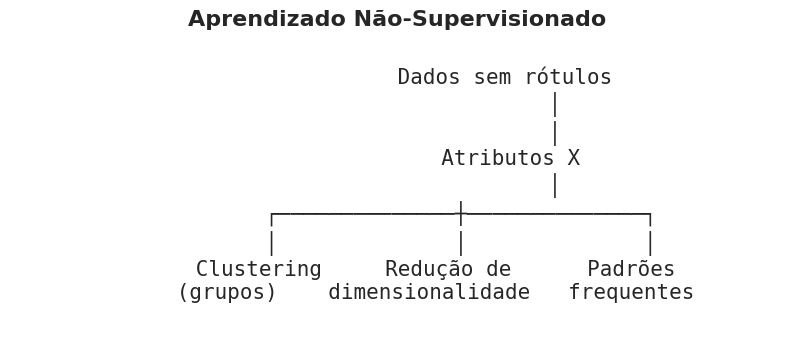

In [ ]:
plt.figure(figsize=(10, 4), dpi=100)
plt.axis("off")

esquema = """
                 Dados sem rótulos
                         │
                         │
                  Atributos X
                         │
          ┌──────────────┼──────────────┐
          │              │              │
      Clustering     Redução de      Padrões
      (grupos)    dimensionalidade   frequentes
"""

plt.text(
    0.5, 0.5,
    esquema,
    fontsize=15,
    family="monospace",
    ha="center",
    va="center"
)

plt.title("Aprendizado Não-Supervisionado", fontsize=16, fontweight="bold")
plt.show()

# 3. Agrupamento (Clustering)

O **agrupamento** consiste em particionar objetos em grupos chamados **clusters**.

A ideia central é:

- objetos no mesmo cluster devem ser **semelhantes** entre si;
- objetos em clusters diferentes devem ser **distintos**.

Essa noção depende diretamente de como medimos **distância** ou **similaridade** entre observações.

## 3.1 Medidas de distância

Algumas medidas comuns são:

| Medida | Ideia | Exemplo de uso |
|---|---|---|
| Distância Euclidiana | distância em linha reta | dados numéricos contínuos |
| Distância de Manhattan | soma das diferenças absolutas | trajetos em grade, contagens |


Para duas observações $x=(x_1,x_2,\ldots,x_p)$ e $z=(z_1,z_2,\ldots,z_p)$, a distância euclidiana é:

$$
d(x,z)=\sqrt{\sum_{j=1}^{p}(x_j-z_j)^2}.
$$

In [ ]:
# Exemplo simples de distâncias entre três objetos
X_exemplo = np.array([
    [1, 1],
    [2, 2],
    [8, 8]
])

nomes = ["A", "B", "C"]

dist_euclidiana = pairwise_distances(X_exemplo, metric="euclidean")
dist_manhattan = pairwise_distances(X_exemplo, metric="manhattan")

print("Distância Euclidiana")
display(pd.DataFrame(dist_euclidiana, index=nomes, columns=nomes).round(2))

print("Distância de Manhattan")
display(pd.DataFrame(dist_manhattan, index=nomes, columns=nomes).round(2))

Distância Euclidiana


,A,B,C
A,0.00,1.41,9.90
B,1.41,0.00,8.49
C,9.90,8.49,0.00


Distância de Manhattan


,A,B,C
A,0.0,2.0,14.0
B,2.0,0.0,12.0
C,14.0,12.0,0.0


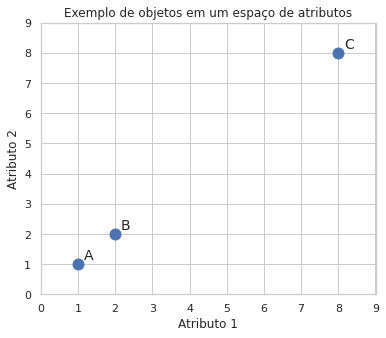

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(X_exemplo[:, 0], X_exemplo[:, 1], s=120)

for nome, (x1, x2) in zip(nomes, X_exemplo):
    plt.text(x1 + 0.15, x2 + 0.15, nome, fontsize=14)

plt.title("Exemplo de objetos em um espaço de atributos")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.xlim(0, 9)
plt.ylim(0, 9)
plt.grid(True)
plt.show()

# 4. K-médias

O **K-médias (K-Means)** é um dos algoritmos de agrupamento mais utilizados em Aprendizado Não-Supervisionado.

Seu objetivo é dividir um conjunto de observações em **K grupos**, de forma que os objetos dentro de um mesmo grupo sejam semelhantes entre si e diferentes dos objetos pertencentes aos demais grupos.

O algoritmo é:

- particional;
- baseado em protótipos;
- iterativo;
- dependente da definição prévia do número de grupos $K$.

Cada grupo é representado por um **centroide**, que corresponde ao ponto médio das observações pertencentes ao cluster.

## 4.1 Como o algoritmo funciona?


Inicialmente, o algoritmo escolhe aleatoriamente $K$ centroides.

Em seguida:

1. Cada observação é associada ao centroide mais próximo.
2. Os centroides são recalculados utilizando a média das observações atribuídas a cada grupo.
3. As observações são novamente atribuídas aos novos centroides.
4. O processo continua até que os centroides parem de se mover significativamente.

Ao final, cada observação pertence a um único cluster.

## 4.2 Função Objetivo

O K-médias procura minimizar a soma das distâncias quadráticas entre cada observação e o centroide do grupo ao qual ela pertence.

Matematicamente:

$$
J = \sum_{i=1}^{K}
\sum_{x \in C_i}
||x-\text{centroide}_i||^2
$$

onde:

- $K$ é o número de clusters;
- $C_i$ representa o cluster $i$;
- $\text{centroide}_i$ representa o centroide do cluster $i$;
- $||x-\text{centroide}_i||^2$ é a distância quadrática entre uma observação e seu centroide.

Quanto menor esse valor, mais compactos são os grupos formados.


## Vantagens

- Simples de implementar;
- Fácil de interpretar;
- Computacionalmente eficiente;
- Funciona bem em bases de dados grandes.

## Limitações

- É necessário definir $K$ antecipadamente;
- Sensível à escolha inicial dos centroides;
- Sensível a outliers;
- Funciona melhor quando os clusters possuem formato aproximadamente esférico;
- Pode apresentar resultados diferentes em execuções distintas.

Por essa razão, normalmente executamos o algoritmo várias vezes com diferentes inicializações e escolhemos a melhor solução encontrada.

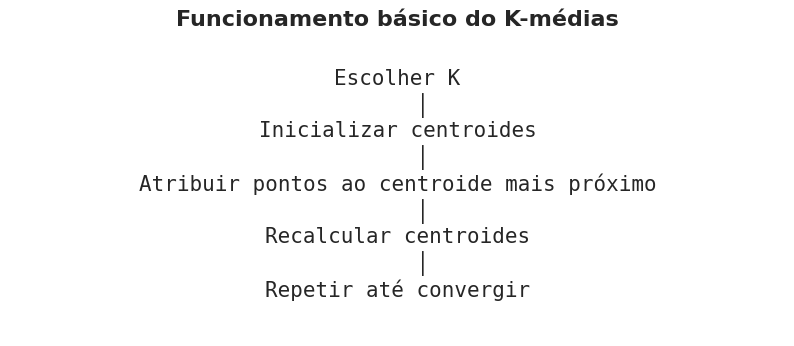

In [ ]:
plt.figure(figsize=(10, 4), dpi=100)
plt.axis("off")

kmeans_esquema = """
Escolher K
    │
Inicializar centroides
    │
Atribuir pontos ao centroide mais próximo
    │
Recalcular centroides
    │
Repetir até convergir
"""

plt.text(
    0.5, 0.5,
    kmeans_esquema,
    fontsize=15,
    family="monospace",
    ha="center",
    va="center"
)

plt.title("Funcionamento básico do K-médias", fontsize=16, fontweight="bold")
plt.show()

## 4.2 Exemplo artificial

Antes de usar a base Iris, vamos gerar uma base artificial com três grupos visuais.

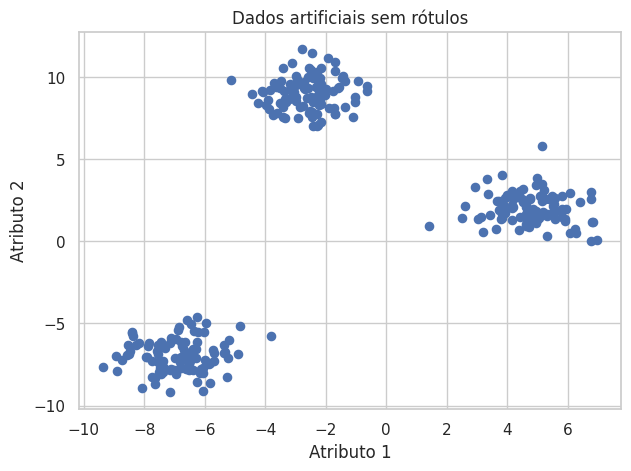

In [ ]:
X_blob, y_blob = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

plt.figure(figsize=(7, 5), dpi=100)
plt.scatter(X_blob[:, 0], X_blob[:, 1], s=35)
plt.title("Dados artificiais sem rótulos")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.show()

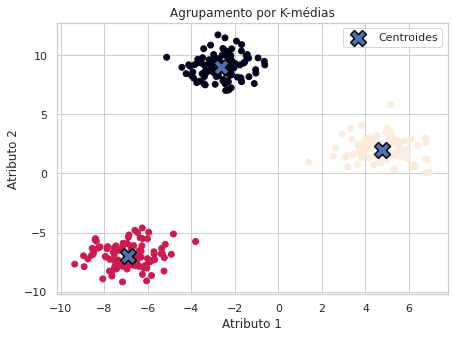

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_blob)
centroides = kmeans.cluster_centers_

plt.figure(figsize=(7, 5))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=clusters, s=35)
plt.scatter(
    centroides[:, 0],
    centroides[:, 1],
    marker="X",
    s=250,
    edgecolor="black",
    linewidth=1.5,
    label="Centroides"
)
plt.title("Agrupamento por K-médias")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.legend()
plt.show()

## 4.3 Como escolher K? Método do cotovelo

O K-médias exige que o número de clusters seja escolhido antes do ajuste.

Uma abordagem exploratória é o **método do cotovelo** (*elbow method*). Calculamos a soma dos quadrados dentro dos grupos para diferentes valores de $K$ e procuramos um ponto em que a redução deixa de ser tão expressiva.

No `scikit-learn`, essa soma é armazenada no atributo `inertia_`.

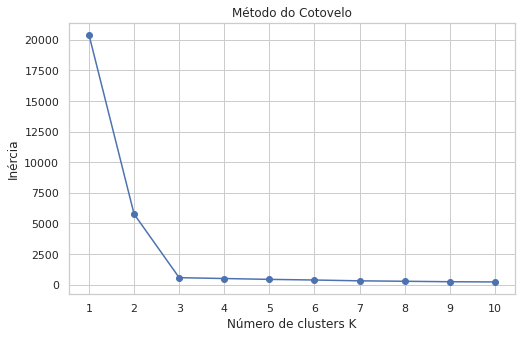

In [ ]:
inercias = []
valores_k = range(1, 11)

for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_blob)
    inercias.append(modelo.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(valores_k, inercias, marker="o")
plt.xticks(valores_k)
plt.xlabel("Número de clusters K")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.show()

## 4.4 Coeficiente de Silhueta

O **coeficiente de silhueta** mede simultaneamente:

- a coesão interna do cluster (quão próximas estão as observações do mesmo grupo);
- a separação entre clusters (quão distante está uma observação dos demais grupos).

Para cada observação, calculam-se:

- \(a(i)\): distância média da observação para todas as demais observações do mesmo cluster;
- \(b(i)\): menor distância média da observação para observações de outro cluster.

O coeficiente de silhueta da observação \(i\) é dado por:

$$s(i)=\frac{b(i)-a(i)}
{\max(a(i),b(i))}$$

onde:

- \(s(i)\) = coeficiente de silhueta da observação;
- \(a(i)\) = distância média intra-cluster;
- \(b(i)\) = distância média ao cluster vizinho mais próximo.

O coeficiente assume valores entre -1 e 1.

### Interpretação

| Valor de \(s(i)\) | Interpretação |
|-------------------|---------------|
| Próximo de 1 | Observação muito bem agrupada |
| Próximo de 0 | Observação próxima da fronteira entre clusters |
| Menor que 0 | Observação possivelmente atribuída ao cluster errado |

O coeficiente de silhueta global é obtido pela média dos coeficientes de todas as observações.

Em geral:

- valores acima de 0,70 indicam excelente separação;
- valores entre 0,50 e 0,70 indicam boa estrutura de agrupamento;
- valores abaixo de 0,25 sugerem que os clusters podem não estar bem definidos.

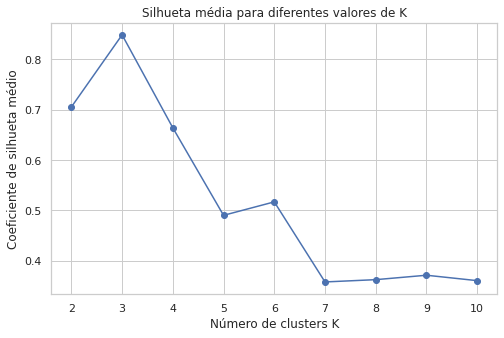

In [ ]:
silhuetas = []
valores_k = range(2, 11)

for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(X_blob)
    silhuetas.append(silhouette_score(X_blob, labels))

plt.figure(figsize=(8, 5))
plt.plot(valores_k, silhuetas, marker="o")
plt.xticks(valores_k)
plt.xlabel("Número de clusters K")
plt.ylabel("Coeficiente de silhueta médio")
plt.title("Silhueta média para diferentes valores de K")
plt.show()

# 5. Agrupamento Hierárquico Aglomerativo

O agrupamento hierárquico aglomerativo começa considerando cada observação como um cluster individual. Em seguida, os clusters mais próximos são fundidos progressivamente.

O resultado pode ser visualizado por meio de um **dendrograma**, que mostra a sequência de fusões.

Critérios comuns de ligação (*linkage*):

| Critério | Ideia |
|---|---|
| `simples (single)` | menor distância entre pontos de dois grupos |
| `completa (complete)` | maior distância entre pontos de dois grupos |
| `média (average)` | distância média entre pontos de dois grupos |
| `ward` | minimiza o aumento da variância dentro dos grupos |

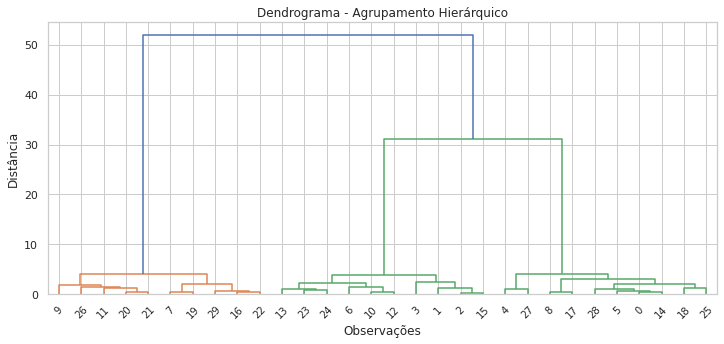

In [ ]:
# Exemplo pequeno para dendrograma
X_hier, y_hier = make_blobs(
    n_samples=30,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

Z = linkage(X_hier, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title("Dendrograma - Agrupamento Hierárquico")
plt.xlabel("Observações")
plt.ylabel("Distância")
plt.show()

# 6. Aplicação com a base Iris

Agora vamos aplicar métodos não-supervisionados à base **Iris**.

A base possui rótulos verdadeiros das espécies, mas eles serão usados apenas no final, para comparação didática. Durante o agrupamento, os algoritmos usarão somente as quatro medidas das flores.

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target
nomes_classes = iris.target_names
nomes_atributos = iris.feature_names

dados = pd.DataFrame(X, columns=nomes_atributos)
dados["especie"] = pd.Categorical.from_codes(y, nomes_classes)

dados.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
print("Dimensão da base Iris:", X.shape)
print("Classes:", nomes_classes)

dados.describe().round(2)

Dimensão da base Iris: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## 6.1 Visualização inicial

Para visualizar os dados em duas dimensões, vamos usar as medidas das pétalas, que costumam separar melhor as espécies.

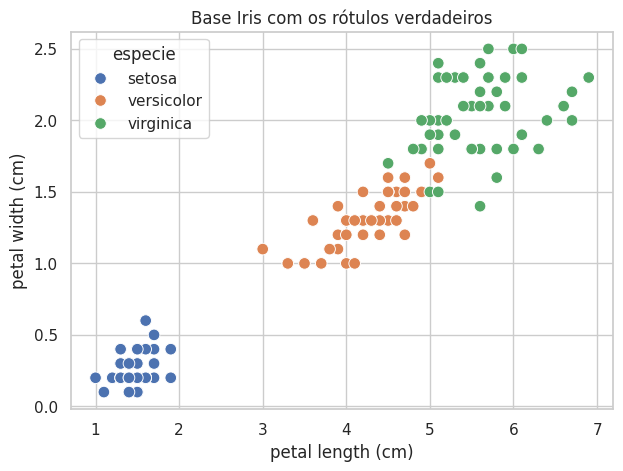

In [ ]:
plt.figure(figsize=(7, 5), dpi=100)
sns.scatterplot(
    data=dados,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="especie",
    s=70
)
plt.title("Base Iris com os rótulos verdadeiros")
plt.show()

## 6.2 Padronização dos dados

Algoritmos baseados em distância são sensíveis à escala das variáveis. Por isso, antes de aplicar K-médias ou agrupamento hierárquico, é recomendável padronizar os atributos.

In [ ]:
escalador = StandardScaler()
X_pad = escalador.fit_transform(X)

pd.DataFrame(X_pad, columns=nomes_atributos).head().round(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.901,1.019,-1.340,-1.315
1,-1.143,-0.132,-1.340,-1.315
2,-1.385,0.328,-1.397,-1.315
3,-1.507,0.098,-1.283,-1.315
4,-1.022,1.249,-1.340,-1.315


## 6.3 Redução para duas dimensões com PCA

Para visualizar os clusters, vamos projetar os dados padronizados em duas componentes principais.

A redução de dimensionalidade aqui é usada apenas para visualização.

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_pad)

print("Variância explicada por componente:")
print(pca.explained_variance_ratio_.round(3))
print("Variância total explicada:", pca.explained_variance_ratio_.sum().round(3))

iris_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
iris_pca["especie"] = dados["especie"]
iris_pca.head()

Variância explicada por componente:
[0.73  0.229]
Variância total explicada: 0.958


,PC1,PC2,especie
0,-2.264703,0.480027,setosa
1,-2.080961,-0.674134,setosa
2,-2.364229,-0.341908,setosa
3,-2.299384,-0.597395,setosa
4,-2.389842,0.646835,setosa


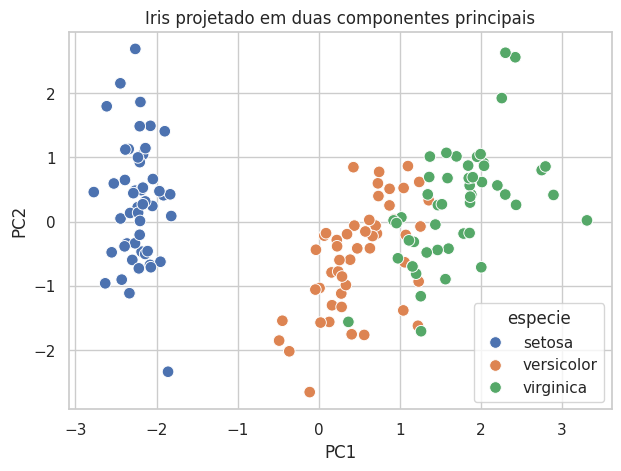

In [ ]:
plt.figure(figsize=(7, 5), dpi=100)
sns.scatterplot(
    data=iris_pca,
    x="PC1",
    y="PC2",
    hue="especie",
    s=70
)
plt.title("Iris projetado em duas componentes principais")
plt.show()

# 7. K-médias na base Iris

Vamos aplicar K-médias usando $K=3$, pois sabemos que a base Iris possui três espécies. Em uma situação real não-supervisionada, esse valor precisaria ser investigado.

In [ ]:
kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_kmeans = kmeans_iris.fit_predict(X_pad)

iris_pca["cluster_kmeans"] = clusters_kmeans
iris_pca.head()

,PC1,PC2,especie,cluster_kmeans
0,-2.264703,0.480027,setosa,1
1,-2.080961,-0.674134,setosa,1
2,-2.364229,-0.341908,setosa,1
3,-2.299384,-0.597395,setosa,1
4,-2.389842,0.646835,setosa,1


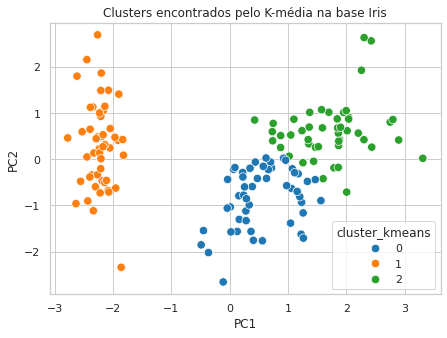

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=iris_pca,
    x="PC1",
    y="PC2",
    hue="cluster_kmeans",
    palette="tab10",
    s=70
)
plt.title("Clusters encontrados pelo K-média na base Iris")
plt.show()

In [ ]:
comparacao = pd.crosstab(
    dados["especie"],
    iris_pca["cluster_kmeans"],
    rownames=["Espécie verdadeira"],
    colnames=["Cluster K-média"]
)

comparacao

Cluster K-média,0,1,2
Espécie verdadeira,,,
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


A tabela cruzada acima não deve ser interpretada como uma matriz de confusão tradicional, pois o K-means não conhece os nomes das classes.

O número do cluster é arbitrário. O importante é verificar se as espécies tendem a se concentrar em grupos diferentes.

## 7.1 Método do cotovelo no Iris

Vamos calcular a inércia para diferentes valores de $K$.

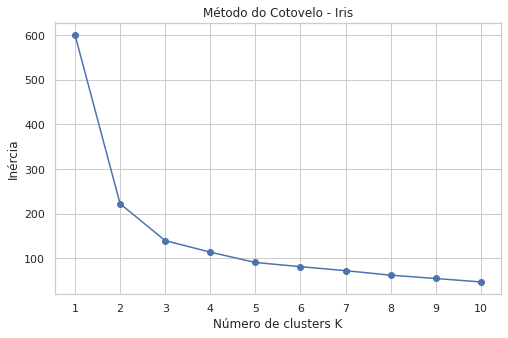

In [ ]:
inercias_iris = []
ks = range(1, 11)

for k in ks:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_pad)
    inercias_iris.append(modelo.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(ks, inercias_iris, marker="o")
plt.xticks(ks)
plt.xlabel("Número de clusters K")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo - Iris")
plt.show()

## 7.2 Silhueta no Iris

Agora vamos calcular a silhueta média para diferentes valores de $K$.

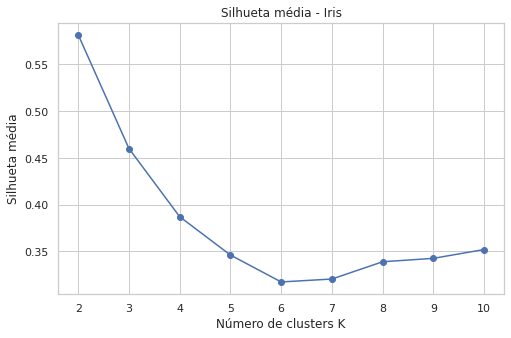

In [ ]:
silhuetas_iris = []
ks = range(2, 11)

for k in ks:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(X_pad)
    silhuetas_iris.append(silhouette_score(X_pad, labels))

plt.figure(figsize=(8, 5))
plt.plot(ks, silhuetas_iris, marker="o")
plt.xticks(ks)
plt.xlabel("Número de clusters K")
plt.ylabel("Silhueta média")
plt.title("Silhueta média - Iris")
plt.show()

# 8. Agrupamento hierárquico na base Iris

Vamos construir um dendrograma usando uma amostra da base Iris para não deixar o gráfico excessivamente carregado.

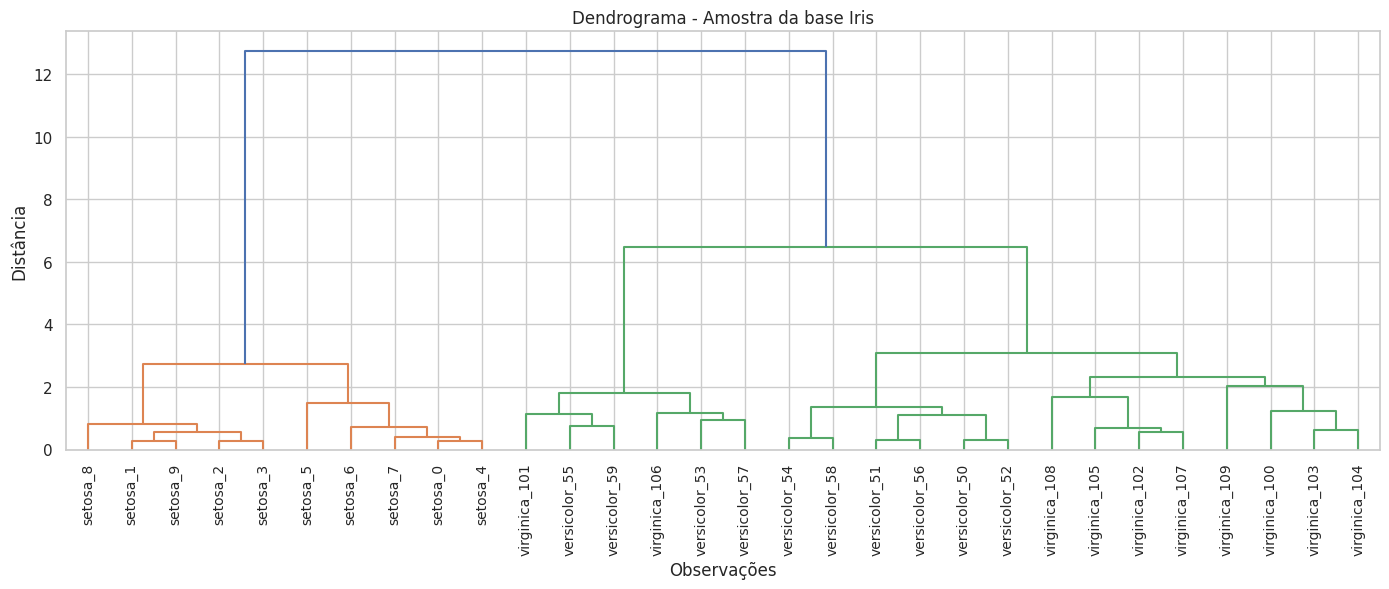

In [ ]:
# Amostra pequena para o dendrograma
idx = np.r_[0:10, 50:60, 100:110]
X_iris_amostra = X_pad[idx]
y_iris_amostra = y[idx]
rotulos = [f"{nomes_classes[y[i]]}_{i}" for i in idx]

Z_iris = linkage(X_iris_amostra, method="ward")

plt.figure(figsize=(14, 6), dpi=100)
dendrogram(Z_iris, labels=rotulos, leaf_rotation=90)
plt.title("Dendrograma - Amostra da base Iris")
plt.xlabel("Observações")
plt.ylabel("Distância")
plt.tight_layout()
plt.show()

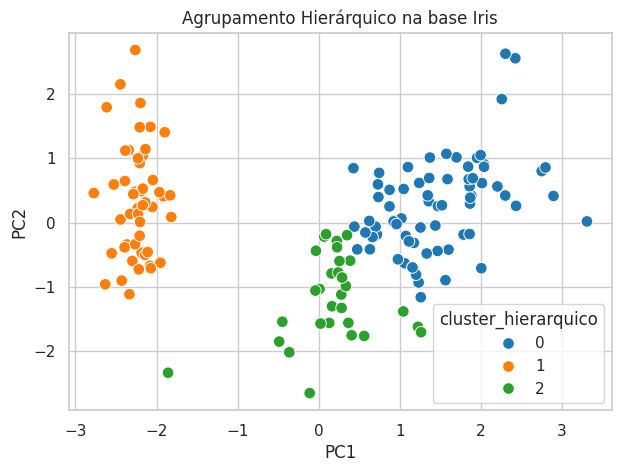

In [ ]:
hier_iris = AgglomerativeClustering(n_clusters=3, linkage="ward")
clusters_hier = hier_iris.fit_predict(X_pad)

iris_pca["cluster_hierarquico"] = clusters_hier

plt.figure(figsize=(7, 5), dpi=100)
sns.scatterplot(
    data=iris_pca,
    x="PC1",
    y="PC2",
    hue="cluster_hierarquico",
    palette="tab10",
    s=70
)
plt.title("Agrupamento Hierárquico na base Iris")
plt.show()

In [ ]:
pd.crosstab(
    dados["especie"],
    iris_pca["cluster_hierarquico"],
    rownames=["Espécie verdadeira"],
    colnames=["Cluster Hierárquico"]
)

Cluster Hierárquico,0,1,2
Espécie verdadeira,,,
setosa,0,49,1
versicolor,23,0,27
virginica,48,0,2


In [ ]:
sil_hier = silhouette_score(X_pad, clusters_hier)

print(f"Silhueta média dos clusters: {sil_hier:.3f}")

Silhueta média dos clusters: 0.447


# 9. Comparação entre métodos no Iris

Vamos comparar K-médias e agrupamento hierárquico usando o método da silhueta média

- **Silhueta média**: mede a coesão e separação dos grupos sem usar rótulos verdadeiros.


In [ ]:
resultados = []

# K-means
resultados.append({
    "Método": "K-médias",
    "Número de grupos": len(np.unique(clusters_kmeans)),
    "Silhueta": silhouette_score(X_pad, clusters_kmeans)
})


# Hierárquico
resultados.append({
    "Método": "Hierárquico",
    "Número de grupos": len(np.unique(clusters_hier)),
    "Silhueta": silhouette_score(X_pad, clusters_hier)
})

tabela_resultados = pd.DataFrame(resultados)
tabela_resultados.round(3)

,Método,Número de grupos,Silhueta
0,K-médias,3,0.460
1,Hierárquico,3,0.447


# 10. Resumo comparativo


| Característica | K-means | Hierárquico |
|----------------|---------|-------------|
| Define número de clusters antes? | Sim | Pode-se escolher o corte do dendrograma |
| Forma típica dos clusters | Convexa / esférica | Depende do critério de ligação (linkage) |
| Sensível à escala dos dados? | Sim | Sim |
| Lida bem com ruído e outliers? | Não explicitamente | Não explicitamente |
| Visualização típica | Gráfico de dispersão e centroides | Dendrograma |
| Custo computacional | Baixo a médio | Alto para bases grandes |


## Pontos importantes

- Em aprendizado não-supervisionado, não há resposta correta observada para guiar o ajuste.
- A interpretação dos clusters depende do contexto do problema.
- A padronização é fundamental quando usamos algoritmos baseados em distância.
- K-médias é simples e eficiente, mas supõe grupos aproximadamente esféricos.
- O agrupamento hierárquico oferece uma visualização rica por dendrogramas.
- Padrões frequentes e regras de associação são tarefas descritivas distintas do clustering.

# 11. Exercícios sugeridos

1. Aplique K-médias na base Iris com $K=2$, $K=3$ e $K=4$. Compare os resultados visualmente.
2. Calcule a silhueta média para cada valor de $K$ e discuta qual parece mais adequado.
3. Gere dendrogramas usando os métodos `simples`, `completa`, `média` e `ward`. Compare as estruturas obtidas.
4. Crie novas transações fictícias e calcule suporte e confiança de outras regras de associação.